In [1]:
from obspy import *
import pandas as pd
import matplotlib.pyplot as plt
from obspy.clients.fdsn import Client
import matplotlib.dates as mdates
import numpy as np
import datetime

This is the calving event that Riley caught on camera. 

Installed new opener with handlers: [<urllib.request.HTTPDigestAuthHandler object at 0x3222e5a50>, <obspy.clients.fdsn.client.NoRedirectionHandler object at 0x322c7c850>]
Base URL: http://10.30.5.28:8080
Request Headers: {'User-Agent': 'ObsPy/1.5.0 (macOS-26.4.1-arm64-arm-64bit, Python 3.11.14)'}
Loading discovered services from cache.
Downloaded http://10.30.5.28:8080/fdsnws/dataselect/1/queryauth?starttime=2026-03-03T15%3A11%3A00.000000&endtime=2026-03-03T15%3A11%3A30.000000&network=%2A&station=I54H2&location=%2A&channel=BDF with HTTP code: 200
Downloaded http://10.30.5.28:8080/fdsnws/station/1/query?starttime=2026-03-03T15%3A10%3A50.300000&endtime=2026-03-03T15%3A11%3A35.950000&network=IM&station=I54H2&location=--&channel=BDF&level=response with HTTP code: 200
No earthquakes for this time period.


/Users/kitsellusted/grad_school/VANDA_work/palmer_picker.py:51: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client.get_waveforms(


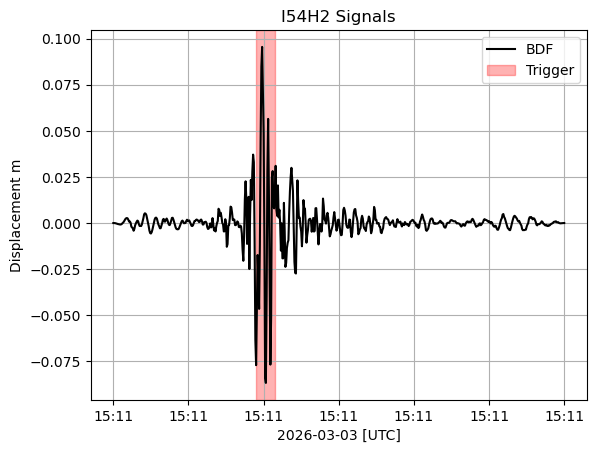

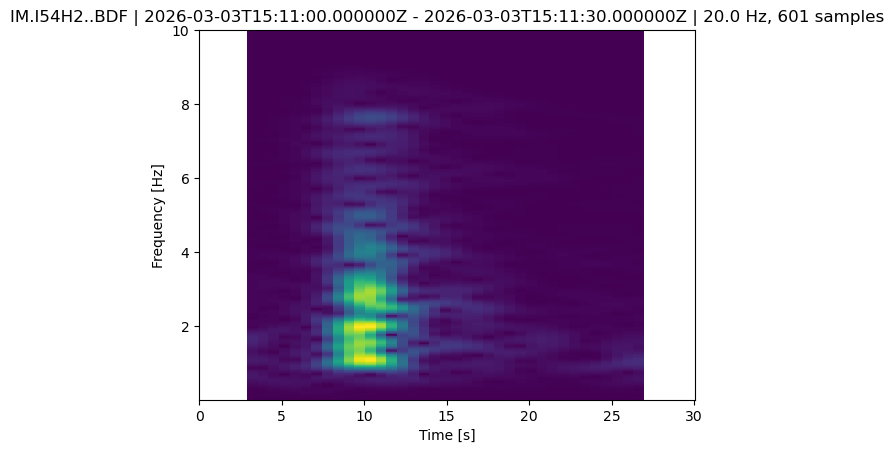

[None]

In [26]:
#Mar Piedmont Glacier Calving Event
%run palmer_picker.py 2026-03-03T15:11 2026-03-03T15:11:30
st.spectrogram()

In [14]:
def stat_plotter(df):
    #Calculate hourly/daily metrics
    hourly_counts = df.groupby(df['local'].dt.hour).size() #in local time
    hour_utc = df.groupby(df['onset'].dt.hour).size() #UTC
    daily_counts = df.groupby(df['local'].dt.day).size() #in local time
    daily_utc = df.groupby(df['onset'].dt.day).size()

    #Plot hourly variation of signal detection
    fig, ax = plt.subplots()
    ax.scatter(df['hour_local'].unique(), hourly_counts, label = 'Palmer Events') #local time
    ax.set_xlabel('Hours in Local Time (UTC+13)')
    ax.set_ylabel('Number of Triggers')
    ax.legend()
    fig.suptitle('Triggers Grouped by Time of Day unfiltered vs filtered')
    
    
    #pick_5 = daily_utc/(24*60) #event time put y-axis in pick per 5 ish min, or pick per minute
    fig, ax = plt.subplots()
    #ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), daily_utc)
    ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), daily_utc/(24), label = 'unfiltered') #pick per hour
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.set_xlabel('Days in UTC Time')
    #ax.set_ylim(5,15)
    ax.set_title("Average Number of Events per Hour")
    ax.set_ylabel('Number of Triggers per Hour')
    ax.legend()
    
    fig.tight_layout(pad=3.0) 

    fig.add_gridspec(4, 4, wspace=0, hspace=0)
   
    #interevent time plot
   
    fig, ax = plt.subplots()
    #ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), daily_utc)
    ax.hist(df['interevent_time'].dt.total_seconds()/60, bins = 80, edgecolor = 'black', label = 'unfiltered') 
    #ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.set_xlabel('Time in Minutes')
    ax.set_title("Interevent Spacing")
    ax.set_ylabel('Occurances')
    ax.legend()
    plt.show()

    fig, ax = plt.subplots()

    #ax = df.groupby(pd.Grouper(key='onset', freq='h')).size().plot(color = 'blue')
    ax = hourly_counts.plot(color = 'red', label = 'filtered')
    ax.set_xlabel('Days in UTC Time')
    ax.set_title("Number of Events per Hour")
    ax.set_ylabel('Number of Triggers per hour')
    #ax.set_ylim(0, 25)
    fig.tight_layout(pad=3.0) 
    fig.legend()
    fig.add_gridspec(8, 8, wspace=0, hspace=0)

    return None
    

In [12]:
#Trigger dataframe stuff
trigger_df = pd.DataFrame(trig_times)

#trigger_df.set_index()
trigger_df[0] = [t.datetime for t in trigger_df[0]]
trigger_df[1] = [t.datetime for t in trigger_df[1]]
trigger_df['month'] = trigger_df[0].dt.month
trigger_df['day'] = trigger_df[0].dt.day
trigger_df['hour_UTC'] = trigger_df[0].dt.hour

#Times in local Antarctica time, better for daylight tracking, diurnal patterns
trigger_df['local'] = trigger_df[0].dt.tz_localize('UTC').dt.tz_convert('Antarctica/McMurdo')
trigger_df['hour_local'] = trigger_df['local'].dt.hour
trigger_df['day_local'] = trigger_df['local'].dt.day
trigger_df.rename(columns={0:'onset', 1:'offset'}, inplace = True)

#Interevent spacing
trigger_df['interevent_time'] = trigger_df['onset'].shift(-1) - trigger_df['offset']

#Hourly and Daily counts
trigger_df["hourly_counts"] = trigger_df.groupby(trigger_df['local'].dt.hour).size() #in local time
hour_utc = trigger_df.groupby(trigger_df['onset'].dt.hour).size() #UTC
daily_counts = trigger_df.groupby(trigger_df['local'].dt.day).size() #in local time
daily_utc = trigger_df.groupby(trigger_df['onset'].dt.day).size()
#trigger_df['amplitude m'] = pd.DataFrame(peak_amps) #amplitude - displacement in meters

trigger_df

,onset,offset,month,day,hour_UTC,local,hour_local,day_local,interevent_time,hourly_counts
0,2026-03-03 15:11:09.500,2026-03-03 15:11:10.750,3,3,15,2026-03-04 04:11:09.500000+13:00,4,4,0 days 00:01:13.350000,NaN
1,2026-03-03 15:12:24.100,2026-03-03 15:12:25.350,3,3,15,2026-03-04 04:12:24.100000+13:00,4,4,NaT,NaN


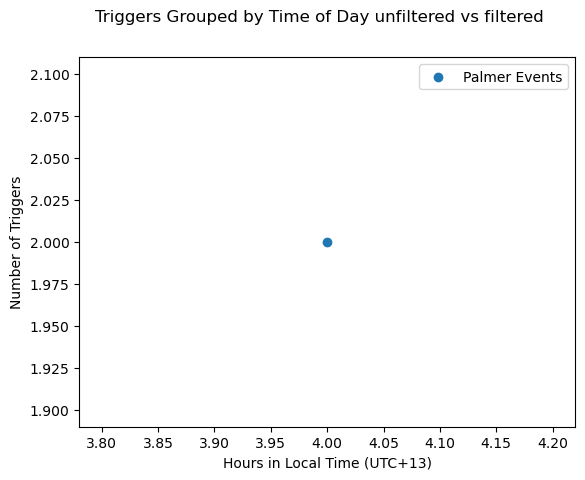

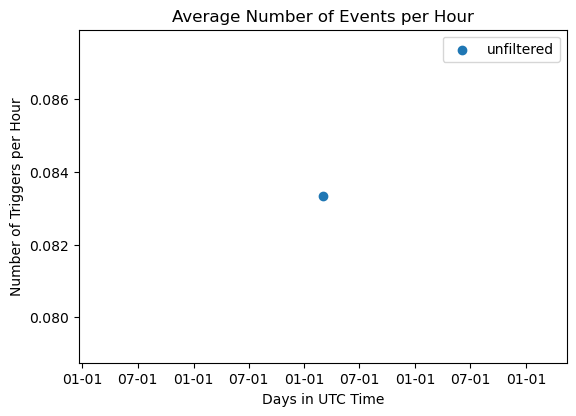

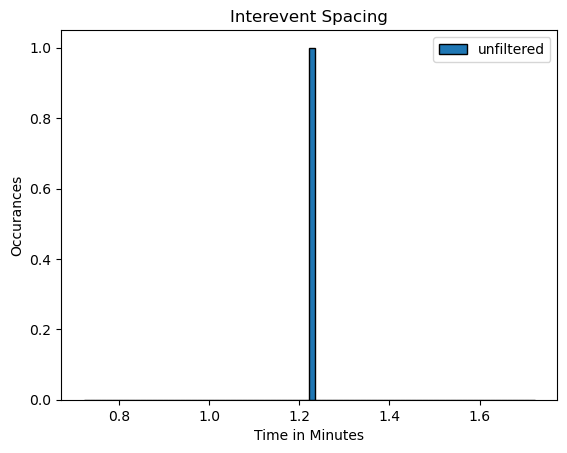

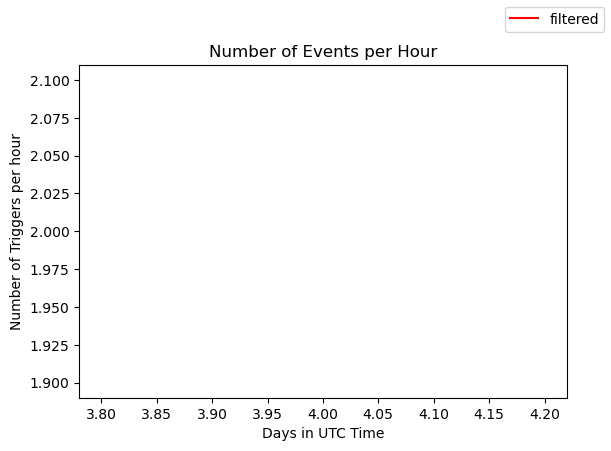

In [16]:
# COMPARING THE FILTERED VS. UNFILTERED TRIGGER PICKS. FILTERING BY TIME INBETWEEN TRIGGERS
#adding in the additional filter by amplitude reduces the likelihood of double picking!
stat_plotter(trigger_df)


## Preparing for Template Matching ##

/Users/kitsellusted/miniconda3/envs/pygmt-env/lib/python3.11/site-packages/obspy/signal/filter.py:87: UserWarning: Selected high corner frequency (10) of bandpass is at or above Nyquist (10.0). Applying a high-pass instead.
  warnings.warn(msg)


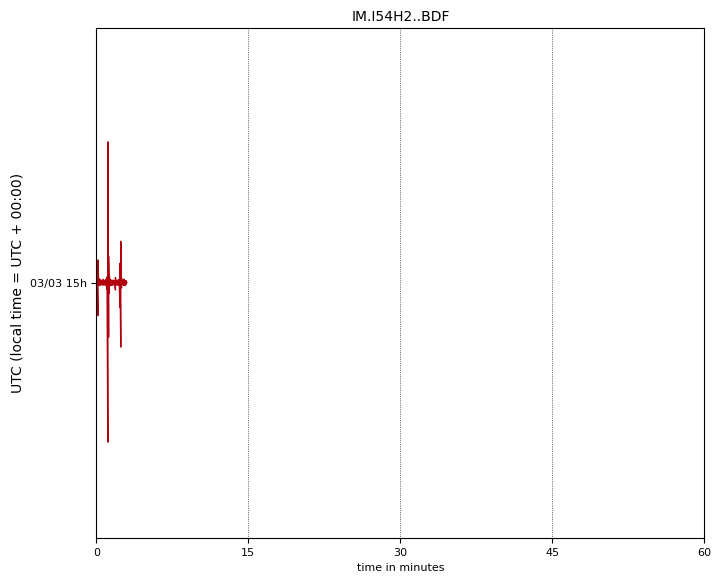

In [17]:
#Dayplots
st.filter("bandpass", freqmin=2, freqmax=10)
for tr in st:
    for i in range(len(pd.to_datetime(trigger_df['onset']).dt.date.unique())):
        start_time = st[0].stats.starttime
        day_start = start_time + (i * 86400)
        day_end = day_start + 86400
        daily_st = st.slice(day_start, day_end)
        local_offset = +13 * 3600
        daily_st.plot(type='dayplot', interval=60, tick_format='%m/%d %Hh', 
                      offset=local_offset,
                      show_y_UTC_label=True  )# interval is minutes per line


In [18]:
#Slices Plotting

sliced_wvf[0].write("signal1.mseed", format="MSEED")

NameError: name 'sliced_wvf' is not defined

In [ ]:
## To DO

#look at data and does it make sense?

#Find 5ish representative signals for future template matching stuff

In [ ]:
#unfilt_min.hist()
#unfilt_min
#unfilt_sec = trigger_df['interevent_time'].dt.total_seconds()
#ax = unfilt_sec.hist()
#ax.set_title('Spread of Calving Events At Palmer')